Flood prediction using K-Nearest Neighbour (KNN) Algorith

In [1]:
#import neccessary library for data analytics
import numpy as np, pandas as pd, matplotlib.pyplot as plt


In [2]:
#import neccessary lbrary for KNN 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [3]:
#tracing the file path
path ="C:\\Users\\ASUS\\Documents\\data_bank\\flood_prediction_dataset.xlsx"

In [4]:
#reading in the dataset
data = pd.read_excel(path)

#view first 10 entries
data.head(10)

,Date,Location,Rainfall (mm),Temperature (°C),Humidity (%),River Level (m),Soil Moisture (%),Flood Risk
0,2023-01-01,CityB,35.9,19.2,52.1,9.44,29.8,0
1,2023-01-02,CityA,235.6,32.2,92.5,2.43,19.7,0
2,2023-01-03,CityA,1.8,29.7,71.2,8.49,32.0,0
3,2023-01-04,CityA,164.8,33.7,50.3,4.53,38.8,0
4,2023-01-05,CityA,50.8,28.5,71.7,4.82,37.9,0
5,2023-01-06,CityC,53.5,13.8,36.1,3.86,28.0,0
6,2023-01-07,CityA,152.4,32.6,77.6,5.36,21.7,0
7,2023-01-08,CityB,142.3,34.6,55.6,7.12,17.4,0
8,2023-01-09,CityB,80.9,17.4,79.6,3.32,40.4,0
9,2023-01-10,CityC,142.7,29.4,62.0,9.29,38.3,0


In [5]:
#inspect the data information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               10000 non-null  datetime64[ns]
 1   Location           10000 non-null  object        
 2   Rainfall (mm)      10000 non-null  float64       
 3   Temperature (°C)   10000 non-null  float64       
 4   Humidity (%)       10000 non-null  float64       
 5   River Level (m)    10000 non-null  float64       
 6   Soil Moisture (%)  10000 non-null  float64       
 7   Flood Risk         10000 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 625.1+ KB


In [6]:
data.describe()

,Rainfall (mm),Temperature (°C),Humidity (%),River Level (m),Soil Moisture (%),Flood Risk
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000
mean,150.815320,22.73913,65.288330,5.502467,27.45563,0.113900
std,86.065119,7.26114,20.110403,2.591013,12.93138,0.317706
min,0.100000,10.00000,30.000000,1.000000,5.00000,0.000000
25%,77.100000,16.50000,48.075000,3.250000,16.50000,0.000000
50%,149.500000,22.80000,65.300000,5.460000,27.30000,0.000000
75%,225.100000,29.10000,82.600000,7.790000,38.60000,0.000000
max,300.000000,35.00000,100.000000,10.000000,50.00000,1.000000


## Flood Prediction 

Note 1:
Location is the only column with object dtype, which typically represents categorical/text data (e.g., city names, regions).

Machine learning models require numerical inputs, so categorical data must be converted.
Date (datetime) can be processed by extracting features (e.g., day, month, year).

Rainfall, Temperature, Humidity, River Level, Soil Moisture are float64 (already numerical).

Flood Risk is int64 (is the target variable for classification)

note 2:

If Location has a limited number of unique values (e.g., 5–50 cities), one-hot encoding is suitable.

If it has high cardinality (e.g., 100+ unique locations), consider target encoding or frequency encoding instead.

In [7]:
#drop the date column , since its irrelevant
data = data.drop('Date', axis=1)
data

,Location,Rainfall (mm),Temperature (°C),Humidity (%),River Level (m),Soil Moisture (%),Flood Risk
0,CityB,35.9,19.2,52.1,9.44,29.8,0
1,CityA,235.6,32.2,92.5,2.43,19.7,0
2,CityA,1.8,29.7,71.2,8.49,32.0,0
3,CityA,164.8,33.7,50.3,4.53,38.8,0
4,CityA,50.8,28.5,71.7,4.82,37.9,0
...,...,...,...,...,...,...,...
9995,CityD,273.9,30.8,72.6,2.10,36.9,0
9996,CityA,84.9,10.4,73.7,1.55,33.1,0
9997,CityA,214.2,30.1,78.6,5.90,8.0,0
9998,CityA,197.2,31.5,95.7,3.68,38.7,0


In [8]:
# using get_dummies from pandas to build onehot for the DataFrame
data = pd.get_dummies(data, columns=['Location'], prefix='Loc')


In [9]:
#seperate the target from other features
target = data.pop("Flood Risk")
target

0       0
1       0
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: Flood Risk, Length: 10000, dtype: int64

In [10]:
features = data.values
features

array([[ 35.9,  19.2,  52.1, ...,   1. ,   0. ,   0. ],
       [235.6,  32.2,  92.5, ...,   0. ,   0. ,   0. ],
       [  1.8,  29.7,  71.2, ...,   0. ,   0. ,   0. ],
       ...,
       [214.2,  30.1,  78.6, ...,   0. ,   0. ,   0. ],
       [197.2,  31.5,  95.7, ...,   0. ,   0. ,   0. ],
       [ 53.9,  14. ,  38.1, ...,   0. ,   1. ,   0. ]])

In [11]:
#splittingthe dataset into training and test set
x_train, x_test, y_train, y_test=train_test_split(features,target, test_size= 0.29, random_state=0)

In [12]:
#fitting K-NN clissifier to the training set (we use minkowski distance because of mixed data types in the dataset)
classifier= KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
classifier.fit(x_train, y_train)

KNeighborsClassifier()

In [13]:
#predicting the test set result
y_pred= classifier.predict(x_test)

In [14]:
y_pred

array([0, 0, 0, ..., 0, 0, 1], dtype=int64)

## Model Evaluation

In [15]:
#creating the confusion matrix
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test, y_pred)

In [16]:
cm

array([[2473,   70],
       [ 201,  156]], dtype=int64)

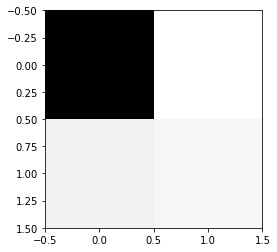

In [17]:
plt.imshow(cm, cmap="binary")

<AxesSubplot:>

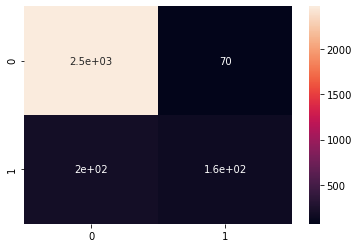

In [18]:
#using seaborn for the heat map
import seaborn as sns
sns.heatmap(cm, annot=True)